# 05 - Business Insights

**Objective:** Synthesize findings across departments, expense categories, and data-quality checks into the final business narrative.

**Business context:** This is the notebook a manager would actually read - it pulls together the headline story from notebooks 01-04 plus the revenue-forecasting and correlation checks that didn't fit neatly into department or category cuts.

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from data_loading import load_dataset
from data_cleaning import clean_dataset
from feature_engineering import engineer_features
import kpi_calculations as kpi


In [2]:
raw = load_dataset()
cleaned, _ = clean_dataset(raw)
df = engineer_features(cleaned)
summary = kpi.kpi_summary(df)
summary

{'record_count': 6780,
 'department_count': 8,
 'total_budget_allocated': 1019783032.04,
 'total_budget_utilized': 978883735.3599999,
 'overall_utilization_rate': 0.9598941192439885,
 'computed_budget_gap': 40899296.68000007,
 'supplied_budget_variance_do_not_use_for_analysis': -360163.99,
 'total_revenue_forecast': 1250614857.8200002,
 'total_actual_revenue': 1202028524.8600001,
 'revenue_realization_rate': 0.9611500433917018,
 'average_allocation_efficiency': 84.04243362831858,
 'budget_status_distribution': {'Efficient': 0.33997050147492625,
  'Inefficient': 0.33436578171091447,
  'Moderate': 0.3256637168141593}}

## Revenue realization rate by department

In [3]:
g = df.groupby('department', observed=True).agg(
    forecast=('revenue_forecast','sum'), actual=('actual_revenue','sum'))
g['realization_rate'] = g['actual'] / g['forecast']
g.sort_values('realization_rate').round(4)

,forecast,actual,realization_rate
department,,,
Operations,1.556175e+08,1.452704e+08,0.9335
Finance,1.513246e+08,1.433531e+08,0.9473
Marketing,1.510175e+08,1.432477e+08,0.9486
IT,1.549172e+08,1.473052e+08,0.9509
HR,1.659662e+08,1.594783e+08,0.9609
Sales,1.569008e+08,1.508356e+08,0.9613
R&D,1.561901e+08,1.520457e+08,0.9735
Logistics,1.586809e+08,1.604925e+08,1.0114


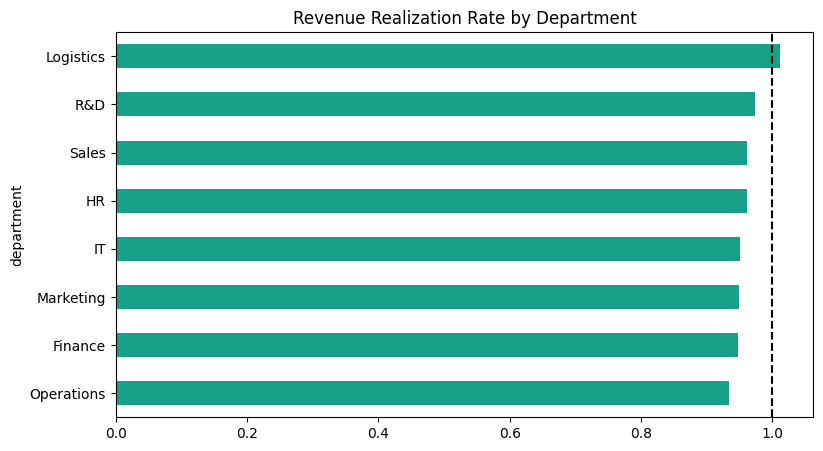

In [4]:
fig, ax = plt.subplots(figsize=(9,5))
g['realization_rate'].sort_values().plot(kind='barh', ax=ax, color='#16a085')
ax.axvline(1.0, color='black', linestyle='--')
ax.set_title('Revenue Realization Rate by Department')
plt.show()

## Correlation check: do macro fields explain budget outcomes here?

In [5]:
corr = df[['inflation_rate','budget_variance_pct','allocation_efficiency',
           'spending_volatility','market_index']].corr()
corr.round(3)

,inflation_rate,budget_variance_pct,allocation_efficiency,spending_volatility,market_index
inflation_rate,1.000,0.019,0.014,0.007,-0.019
budget_variance_pct,0.019,1.000,0.003,-0.014,-0.021
allocation_efficiency,0.014,0.003,1.000,0.008,0.014
spending_volatility,0.007,-0.014,0.008,1.000,-0.014
market_index,-0.019,-0.021,0.014,-0.014,1.000


**Interpretation:** Every pairwise correlation is below |r| = 0.03 - negligible. This dataset does not support claims that inflation, market conditions, or spending volatility drive budget outcomes. See `docs/assumptions_and_constraints.md` item 5-6.

## Overspent / underspent record share (the headline nuance)

In [6]:
print('Overspent share:', df['is_overspent'].mean())
print('Underspent share:', df['is_underspent'].mean())

Overspent share: 0.4685840707964602
Underspent share: 0.30117994100294987


## Final Business Insights

1. **The aggregate utilization rate (96.0%) looks healthy but hides that 47% of records are overspent and 30% are meaningfully underspent** - report both figures together, not the aggregate alone.
2. **Finance/Operations, IT/Salaries, and Finance/Training are the top three investigation candidates**, each averaging 125-130% utilization.
3. **Operations and Finance have the weakest revenue-forecast accuracy** (93.4% and 94.7% realization respectively); Logistics is the only department where actuals beat forecast.
4. **No department is a systemic 'Inefficient' outlier** - Budget_Status is evenly spread (32-35% Inefficient share in every department).
5. **Macro fields (inflation, market index, volatility) show no meaningful correlation with outcomes** in this dataset - don't build a predictive story on them here.

Full finding-by-finding detail with evidence: `docs/findings.md`.
Recommended actions: `docs/recommendations.md`.